<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

# `Instrucciones Generales`


## `Temas formales`

**Modalidad**: Grupos de 3 personas.

**Formato de entrega:** El trabajo debe entregarse a través de Canvas, tanto en formato Jupyter ejecutable (.ipynb) como en formato PDF.

**Formalidades de las respuestas:**
- Citas: APA 7.
- Se espera buena ortografía y redacción, con respuestas en tono académico.

## `Recomendaciones`

- Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes.

- **Lean la rúbrica antes de hacer su tarea.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA sigue los lineamientos de integridad académica del curso, con las siguientes excepciones:

- Pueden usar IA para consultar por bugs y entender mejor el código.
- Pueden usar IA para generar las representaciones visuales que estimen convenientes.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3

---
## `Contexto`

La Encuesta de Caracterización Socioeconómica Nacional [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen) cumple un rol fundamental en la toma de decisiones para la formulación de políticas sociales en Chile. Los organismos gubernamentales buscan estimar la realidad de la población, por lo que cualquier modelo predictivo construido a partir de estos datos tiene la capacidad de influir en la asignación de recursos y en la formulación de políticas públicas.

En ese sentido, un modelo que prediga la situación socioeconómica de la población puede transformarse en una herramienta con gran poder y grandes riegos.

Como científicos de datos, a menudo nos enfrentamos a este tipo de situaciones mediante dos preguntas: ¿cómo resolver automáticamente un problema de clasificación? Y, quizás más importante, ¿qué puede salir mal cuando ese modelo toma decisiones que afectan a personas?

En este taller entrenarán un modelo predictivo de pobreza multidimensional (`pobreza_multi`) utilizando el [dataset preprocesado](https://drive.google.com/file/d/15NMlO4BD-OB55uvfYWUSCh_ba4-zCzI8/view?usp=drive_link) de la encuesta [CASEN 2024](https://observatorio.ministeriodesarrollosocial.gob.cl/encuesta-casen).

El objetivo es detectar posibles sesgos en las predicciones, evaluar si el modelo es justo para distintos grupos de la población, aplicar técnicas de mitigación y discutir los riesgos de automatizar este tipo de problemas de clasificación.

---

## Parte 1

Lea la [**Metodología de Diseño Muestral CASEN 2024**](https://drive.google.com/file/d/1VafJ57Ta6_gwUM-8sir6PAw5DVuBh0rq/view?usp=sharing), específicamente la sección *Antecedentes y características generales del diseño*, y revise el [**libro de códigos de la base de datos CASEN 2024**](https://docs.google.com/spreadsheets/d/1x25URkqJy7Ncc61VEc75NE7XKFsrUHw5/edit?gid=937549388#gid=937549388) para entender las variables disponibles.

Antes de escribir una sola línea de código, lean los materiales de contexto mencionados anteriormente. Deben comprender por qué se levanta la encuesta CASEN, qué mide la variable `pobreza_multi`

### **RESPONDER**

1.  Discuta los objetivos de la encuenstra CASEN con referencias a la metodología y  para qué serviría entrenar  un clasificador automático de este tipo.

La encuesta Casen es uno de los principales instrumentos utilizados en Chile para conocer las condiciones socioeconómicas de los hogaress del país y realizar seguimiento a las políticas sociales. Según la "Metodología de Diseño Muestral Casen 2024", la encuesta busca conocer periódicamente la situación de los hogares y de la población, con foco en quienes se encuentran en situación de pobreza y a los grupos considerados prioritarios para políticas sociales. Para esto, recopila antecedentes relacionados con aspectos demográficos, esducación, salud, vivienda, trabajo e ingresos, lo que permite estimar la magnitud de pobreza, identificar carencias y analizar brechas entre distintos grupos sociales y territorios. Además, busca evaluar aspectos de política social como cobertura de programas y distribución del gasto social entre los hogares.

La variable *pobreza_multi*, corresponde a la situación de pobreza multidimensional. Es un enfoque que busca representar privaciones simultáneas en diferentes ámbitos de las condiciones de vida. La metodología aplicada el 2024 considera cinco dimensiones, siendo estas Educación, Salud, Trabajo y Seguridad Social, Vivienda y Entorno, y Redes y Cohesión Social. Cada una de estas dimensiones representa un 20% del índice y están compuestas por 4 indicadores con un 5% de ponderación cada uno. Un hogar se considera en situación de pobreza multidimensional cuando la suma ponderada de sus carencias es mayor al 20%, lo que es equivalente a presentar al menos cinco indicadores en carencia.

La medición tiene como objetivos obtener un diagnóstico mas comprensivo de la pobreza en Chile y constituir un instrumento útil para diseñar, implementar, monitorear y evaluar politicas públicas. Es por esto que entrenar un clasificador capaz de predecir la pobreza multidimensional podría servir como herramienta de análsisi para poder detectar patrones asociados a la pobreza multidimensional, estudiar que caracterísiticas permiten distinguir a la población con mas carencias o estudiar mecanismos de priorización.

Adempas, el uso de un clasificador presenta un riesgo importante. Un falso negativo correspondería a una persona u hogar que se encuentra en pobreza multidimensional pero que no es clasificado como pobre por el modelo.  Esto, podría producir errores o exclusión en las asignaciones de beneficios a personas que requieren apoyo.

Referencias:
* Ministerio de Desarrollo Social y Familia. (2026a). Metodología de diseño muestral Casen 2024. División Observatorio Social.
* Ministerio de Desarrollo Social y Familia. (2026b). Metodología de medición de la pobreza multidimensional en Chile: Actualización 2024. División Observatorio Social.


## Librerias y configuraciones

In [19]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn - importa aquí las librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# aequitas
from aequitas.group import Group

# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset


import warnings
warnings.filterwarnings("ignore")

## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir el nivel de pobreza multidimensional (pobreza_multi). Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

*Puede reutilizar el jupyter o trabajar con el mismo jupyter de la entrega anterior, puede entregar una carpeta con ambos jupyter y funciones compartidas*

### Indicaciones

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables númericas y tratamiento de valores extremos

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La clase pobreza_multi está desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.


### **RESPONDER**

2.1 Explique y justifique los pasos del preprocesamiento.

2.2 ¿Podemos concluír con esto que el modelo tiene el mismo rendimiento para todos los grupos demográficos?


In [20]:
df_casen = pd.read_csv("data/casen_2024.csv")
print("Dimensiones: ", df_casen.shape)

display(df_casen.head())

print("\ndistribución de pobreza_multi: ")
print(df_casen["pobreza_multi"].value_counts())

print("\nPorcentaje:")
print(df_casen["pobreza_multi"].value_counts(normalize=True) * 100)


Dimensiones:  (212471, 42)


,area,p1,p2,p3,p4,p9,tot_per_h,edad,sexo,ind_hacina,...,v22,v23,v24,v24b,v27a,v27b,v29b,os1,trans,pobreza_multi
0,Urbano,Casa acceso directo,3,3,3,2,2,62,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
1,Urbano,Casa acceso directo,3,3,3,2,2,92,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,40000.0,1.0,1.0,1.0,Heterosexual,No,No pobre
2,Urbano,Casa acceso directo,3,3,4,4,4,61,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
3,Urbano,Casa acceso directo,3,3,4,4,4,61,Mujer,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre
4,Urbano,Casa acceso directo,3,3,4,4,4,32,Hombre,1,...,Llave dentro vivienda,1,Red pública medidor propio,28000.0,3.0,1.0,1.0,Heterosexual,No,No pobre



distribución de pobreza_multi: 
pobreza_multi
No pobre    174979
Pobre        37492
Name: count, dtype: int64

Porcentaje:
pobreza_multi
No pobre    82.354298
Pobre       17.645702
Name: proportion, dtype: float64


In [21]:
y = df_casen["pobreza_multi"].map({
    "No pobre": 0,
    "Pobre": 1
})

X = df_casen.drop(columns=["pobreza_multi"]).copy()

print(y.value_counts())

pobreza_multi
0    174979
1     37492
Name: count, dtype: int64


In [22]:
columnas_categoricas_numericas = [
    "p2",
    "p3",
    "p4",
    "ind_hacina",
    "o1",
    "h7e",
    "h7f",
    "r14",
    "r17a",
    "r17b",
    "r17c",
    "v3",
    "v5",
    "v23"
]

for columna in columnas_categoricas_numericas:
    X[columna] = X[columna].astype("string")

In [23]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Copias que modificaremos
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Tamaño entrenamiento: (169976, 41)
Tamaño test: (42495, 41)

Distribución entrenamiento:
pobreza_multi
0    0.823546
1    0.176454
Name: proportion, dtype: float64

Distribución test:
pobreza_multi
0    0.823532
1    0.176468
Name: proportion, dtype: float64


In [24]:
# Revisa si hay valores
nulos = df_casen.isnull().sum()

print(
    nulos[nulos > 0]
)

Series([], dtype: int64)


In [25]:
# Tratamiento por si igualmente hubieran datos faltantes
columnas_numericas = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

columnas_categoricas = [
    columna
    for columna in X_train.columns
    if columna not in columnas_numericas
]

print("Variables numéricas:")
print(columnas_numericas)

print("\nCantidad de variables categóricas:")
print(len(columnas_categoricas))

Variables numéricas:
['p9', 'tot_per_h', 'edad', 'v24b', 'v27a', 'v27b', 'v29b']

Cantidad de variables categóricas:
34


In [26]:
# Imputación preventiva
# Variables numéricas: mediana
for columna in columnas_numericas:

    mediana = X_train[columna].median()

    X_train[columna] = X_train[columna].fillna(mediana)
    X_test[columna] = X_test[columna].fillna(mediana)


# Variables categóricas: moda
for columna in columnas_categoricas:

    moda = X_train[columna].mode(dropna=True)

    if len(moda) > 0:
        valor_reemplazo = moda.iloc[0]
    else:
        valor_reemplazo = "Sin dato"

    X_train[columna] = X_train[columna].fillna(
        valor_reemplazo
    )

    X_test[columna] = X_test[columna].fillna(
        valor_reemplazo
    )

In [27]:
#Tratamiento de valores extremos
# Se utiliza el rango intercuartílico (IQR)

limites_outliers = {}

for columna in columnas_numericas:

    q1 = X_train[columna].quantile(0.25)
    q3 = X_train[columna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    limites_outliers[columna] = (
        limite_inferior,
        limite_superior
    )

    # Si IQR = 0, no hacemos clipping
    if iqr > 0:

        X_train[columna] = X_train[columna].clip(
            limite_inferior,
            limite_superior
        )

        X_test[columna] = X_test[columna].clip(
            limite_inferior,
            limite_superior
        )

In [28]:
# Normalización
scaler = MinMaxScaler()

X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)


In [29]:
# Codificación de variables categóricas
# Se aplica one-hot encodeing

X_train = pd.get_dummies(
    X_train,
    columns=columnas_categoricas,
    dtype=np.uint8
)

X_test = pd.get_dummies(
    X_test,
    columns=columnas_categoricas,
    dtype=np.uint8
)



In [30]:
# Iguala columnas en caso de que una categoría aparezca en entrenamiento
# y no en test

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Dimensiones X_train:", X_train.shape)
print("Dimensiones X_test:", X_test.shape)

Dimensiones X_train: (169976, 141)
Dimensiones X_test: (42495, 141)


In [34]:
# Entrenamiento del arbol de decisión
# Usa class_weight="balanced", por el desbalance de pobreza_multi
modelo_arbol = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

modelo_arbol.fit(
    X_train,
    y_train
)

#Generamos las predicciones
y_pred = modelo_arbol.predict(
    X_test
)

In [35]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9359
Accuracy: 93.59%


In [36]:
# Matriz de confusión
matriz_confusion = confusion_matrix(
    y_test,
    y_pred
)

print(matriz_confusion)

[[33674  1322]
 [ 1403  6096]]


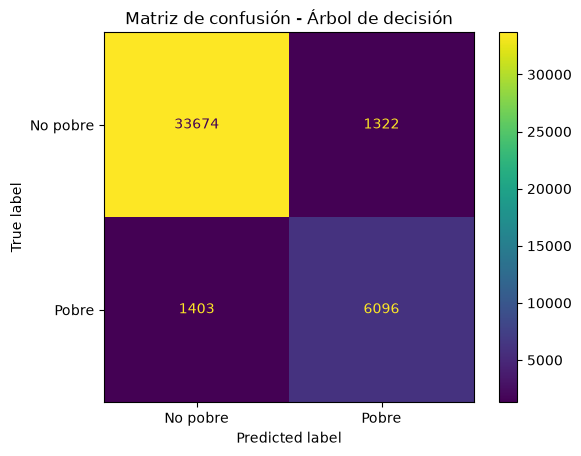

In [38]:
# Gráfico
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=[
        "No pobre",
        "Pobre"
    ]
).plot()

plt.title(
    "Matriz de confusión - Árbol de decisión"
)

plt.show()

Interpretación:
33.635 = No pobres correctamente clasificados
 1.361 = No pobres clasificados como pobres

 1.417 = Pobres clasificados como no pobres --------- OJO CON ESTO, ES IMPORTANTE
 6.082 = Pobres correctamente clasificados

In [39]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No pobre",
            "Pobre"
        ]
    )
)

              precision    recall  f1-score   support

    No pobre       0.96      0.96      0.96     34996
       Pobre       0.82      0.81      0.82      7499

    accuracy                           0.94     42495
   macro avg       0.89      0.89      0.89     42495
weighted avg       0.94      0.94      0.94     42495



## Parte 3: Evalúe las predicciones del modelo mediante las métricas de Fairness de Aequitas.

### **Indicaciones**

Considere como posibles atributos demográficos sensibles: genero, r3 (pertenencia a pueblo indígena), os1 (orientación sexual) y edad_cat; o bien atributos asociados a posibles discapacidades (revise el libro de códigos): h7e y h7f.

**Paso 1: Binarice las variables sensibles.**
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado. Para variables con más de dos categorías, cree una columna auxiliar que agrupe las categorías y justifique su decisión.

**Paso 2: Elija al menos 2 atributos sensibles y defina sus grupos.**

Ejemplos de posibles agrupaciones, y grupos considere que puede elegir sus propias categorizaciones de privilegio y los grupos que estime.:

| Atributo | Grupo | Categoría |
|---|---|---|
| r3 | Privilegiado | no indígena |
| r3 | No privilegiado | indígena |
| os1 | Privilegiado | heterosexual |
| os1 | No privilegiado | otras orientaciones |
| edad_cat | Privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |
| edad_cat | No privilegiado | *(a definir según los intervalos que usted cree, justificando la elección)* |

o, asociados a discapacidad:

| Atributo | Grupo | Categoría |
|---|---|---|
| h7e | Privilegiado | 1. No, ninguna dificultad |
| h7e | No privilegiado | las demás categorías |
| h7f | Privilegiado | 1. No, ninguna dificultad |
| h7f | No privilegiado | las demás categorías |

Pueden

**Paso 3: Reporte las métricas.**
Reporte las métricas de *False Negative Rate Parity* y *False Discovery Rate Parity* para los atributos y grupos definidos.

### **RESPONDER**

Pregunta 3.1 Explique los resultados obtenidos.

Pregunta 3.2 ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionaría esto con los contenidos del curso?

In [31]:
### codigo aquí

## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

### **RESPONDER**

pregunta 4.1: comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [32]:
### codigo aquí

## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [33]:
### codigo aquí